# Notebook 03: Classification

## Objective
Build supervised models to predict diabetes status using held-out validation and test sets.

## Scope
- Load saved train/validation/test splits
- Binary screening task (diabetes vs non-diabetes) with threshold tuning
- Multiclass diagnosis task (0/1/2)
- Compare linear baseline vs tree-based model
- Evaluate with class-aware metrics and visual diagnostics

## Modelling Strategy
- **Logistic Regression:** RobustScaler + regularization; class weights explored; threshold selected on validation to meet target recall for the binary task.
- **LightGBM:** Multiclass gradient boosting with early stopping on validation; class weights balanced.

## Evaluation
- Binary: precision, recall, PR-AUC, confusion matrix, and PR curve.
- Multiclass: balanced accuracy, macro F1, per-class recall, confusion matrix.
- Model interpretability: LR coefficients and SHAP for LightGBM.

## Output
- Trained models and evaluation artifacts (metrics, plots) for reporting and comparison.

In [ ]:
import pickle
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay
)

from sklearn.metrics import balanced_accuracy_score

import lightgbm as lgb
from sklearn.metrics import balanced_accuracy_score

import shap
import matplotlib.pyplot as plt


In [ ]:
# Target recall for binary threshold tuning
TARGET_RECALL = 0.75
# Reproducibility seed
RANDOM_STATE = 42

In [ ]:
# Load the split data
with open('../data/processed_data/split_data.pkl', 'rb') as f:
    data = pickle.load(f)

# Unpack train, validation, and test splits
X_train = data['X_train']
X_val = data['X_val']
y_train = data['y_train']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']

In [ ]:
# Task 1: Binary Classification (0 vs 1 or 2) (Screening)
# Create binary labels for screening
y_train_bin = (y_train > 0).astype(int)
y_val_bin   = (y_val > 0).astype(int)
y_test_bin  = (y_test > 0).astype(int)

def pick_threshold_max_precision_at_min_recall(y_true, prob_pos, min_recall):
    # Compute precision-recall curve for candidate thresholds
    precision, recall, thresholds = precision_recall_curve(y_true, prob_pos)
    # Drop the first point which has no threshold
    precision_t = precision[1:]
    recall_t = recall[1:]

    # Find thresholds that satisfy the minimum recall constraint
    eligible = np.where(recall_t >= min_recall)[0]
    if eligible.size == 0:
        return None, None, None

    # Choose the eligible threshold with maximum precision
    best_idx = eligible[np.argmax(precision_t[eligible])]
    return thresholds[best_idx], precision_t[best_idx], recall_t[best_idx]

# Hyperparameter grids for regularization and class weighting
c_grid = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]
l1_ratio_grid = [0.0, 0.25, 0.5, 0.75, 1.0]
class_weights = [
    None,
    "balanced",
    {0: 1.0, 1: 2.0},
    {0: 1.0, 1: 3.0},
    {0: 1.0, 1: 5.0},
]

# Track the best model by precision under recall constraint
best = {"precision": -1}

# Grid search across C, l1_ratio, and class weights
for C in c_grid:
    for l1r in l1_ratio_grid:
        for cw in class_weights:
            # Build pipeline: scaling + logistic regression
            model = Pipeline([
                ("scaler", RobustScaler()),
                ("clf", LogisticRegression(
                    solver="saga",
                    C=C,
                    l1_ratio=l1r,
                    class_weight=cw,
                    max_iter=10000,
                    tol=1e-4,
                    random_state=RANDOM_STATE
                ))
            ])

            # Fit on training data
            model.fit(X_train, y_train_bin)
            # Predict probabilities on validation data
            val_probs = model.predict_proba(X_val)[:, 1]

            # Select threshold that meets minimum recall
            thr, prec, rec = pick_threshold_max_precision_at_min_recall(
                y_val_bin, val_probs, TARGET_RECALL
            )
            if thr is None:
                continue

            # Update best configuration by precision
            if prec > best["precision"]:
                best.update({
                    "model": model,
                    "threshold": thr,
                    "precision": prec,
                    "C": C,
                    "l1_ratio": l1r,
                    "class_weight": cw
                })

# Report the best validation configuration
print("\n[Task 1] Best Binary LR (selected on VAL)")
print(best)

# Evaluate the selected model/threshold on the held-out test set
test_probs = best["model"].predict_proba(X_test)[:, 1]
test_pred = (test_probs >= best["threshold"]).astype(int)

# Print test metrics for the final model
print("\n=== Binary LR FINAL (TEST) ===")
print("Threshold:", best["threshold"])
print("Recall:", recall_score(y_test_bin, test_pred))
print("Precision:", precision_score(y_test_bin, test_pred))
print("PR-AUC:", average_precision_score(y_test_bin, test_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test_bin, test_pred))


[Task 1] Best Binary LR (selected on VAL)
{'precision': np.float64(0.33996598639455783), 'model': Pipeline(steps=[('scaler', RobustScaler()),
                ('clf',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    l1_ratio=0.25, max_iter=10000,
                                    random_state=42, solver='saga'))]), 'threshold': np.float64(0.5096667148759207), 'C': 0.1, 'l1_ratio': 0.25, 'class_weight': 'balanced'}

=== Binary LR FINAL (TEST) ===
Threshold: 0.5096667148759207
Recall: 0.7550969355847404
Precision: 0.3456429634718882
PR-AUC: 0.4384931328951432
Confusion Matrix:
 [[31312 11429]
 [ 1958  6037]]


<Figure size 550x450 with 0 Axes>

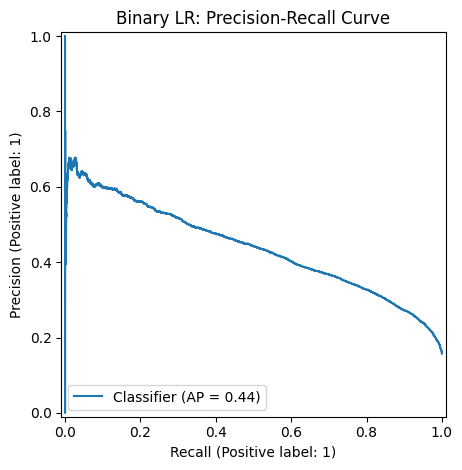

<Figure size 500x450 with 0 Axes>

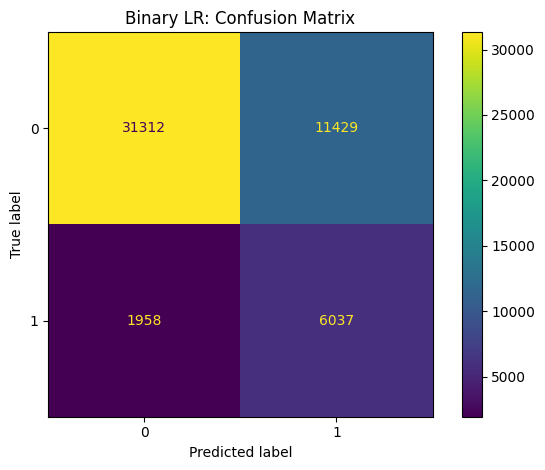

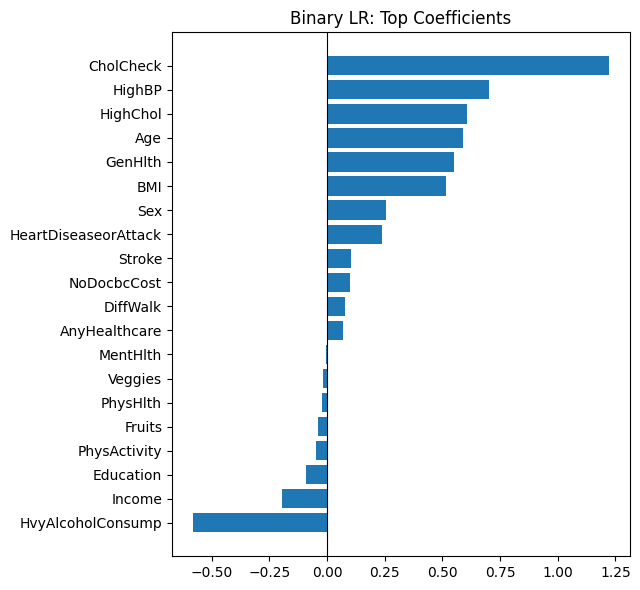

In [ ]:
# Binary LR: PR curve + confusion matrix + coefficient plot
# Load the trained binary LR model
lr_bin = best["model"]
# Compute probabilities and predicted labels
bin_probs = lr_bin.predict_proba(X_test)[:, 1]
bin_pred = (bin_probs >= best["threshold"]).astype(int)

# Precision-recall curve
plt.figure(figsize=(5.5, 4.5))
PrecisionRecallDisplay.from_predictions(y_test_bin, bin_probs)
plt.title("Binary LR: Precision-Recall Curve")
plt.tight_layout()
plt.show()

# Confusion matrix
plt.figure(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test_bin, bin_pred, display_labels=[0, 1])
plt.title("Binary LR: Confusion Matrix")
plt.tight_layout()
plt.show()

# Coefficient importance (top absolute values)
coef = lr_bin.named_steps["clf"].coef_.ravel()
feature_names = np.array(X_train.columns)
top_k = min(20, len(feature_names))
top_idx = np.argsort(np.abs(coef))[-top_k:]
sorted_idx = top_idx[np.argsort(coef[top_idx])]

# Plot top coefficients
plt.figure(figsize=(6.5, 6))
plt.barh(feature_names[sorted_idx], coef[sorted_idx])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Binary LR: Top Coefficients")
plt.tight_layout()
plt.show()

In [ ]:
# Task 2: Multiclass Classification (0 vs 1 vs 2) (Diagnosis)
# Hyperparameter grid for multiclass LR
c_grid = [0.01, 0.03, 0.1, 0.3, 1.0]
class_weights = [None, "balanced"]

# Select by balanced accuracy on validation to handle class imbalance
best_mc = {"ba": -1}

# Grid search across C and class weights
for C in c_grid:
    for cw in class_weights:
        # Build pipeline: scaling + logistic regression
        model = Pipeline([
            ("scaler", RobustScaler()),
            ("clf", LogisticRegression(
                solver="lbfgs",
                C=C,
                class_weight=cw,
                max_iter=3000,
                tol=1e-4,
                random_state=RANDOM_STATE
            ))
        ])

        # Fit on training data
        model.fit(X_train, y_train)
        # Predict on validation data
        val_pred = model.predict(X_val)
        # Compute balanced accuracy on validation
        ba = balanced_accuracy_score(y_val, val_pred)

        # Update best model by balanced accuracy
        if ba > best_mc["ba"]:
            best_mc.update({
                "model": model,
                "ba": ba,
                "C": C,
                "class_weight": cw
            })

# Report the best validation configuration
print("\n[Task 2] Best Multiclass LR (selected on VAL)")
print(best_mc)

# Evaluate the selected model on the held-out test set
test_pred = best_mc["model"].predict(X_test)

# Print test metrics for the final model
print("\n=== Multiclass LR FINAL (TEST) ===")
print("Balanced Accuracy:", balanced_accuracy_score(y_test, test_pred))
print("Macro Recall:", recall_score(y_test, test_pred, average="macro"))
print("Macro F1:", f1_score(y_test, test_pred, average="macro"))
print("Per-class Recall:", recall_score(y_test, test_pred, average=None))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_pred))


[Task 2] Best Multiclass LR (selected on VAL)
{'ba': 0.5119116700179777, 'model': Pipeline(steps=[('scaler', RobustScaler()),
                ('clf',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=3000, random_state=42))]), 'C': 0.01, 'class_weight': 'balanced'}

=== Multiclass LR FINAL (TEST) ===
Balanced Accuracy: 0.5280886549992199
Macro Recall: 0.5280886549992199
Macro F1: 0.42925772440576065
Per-class Recall: [0.66294659 0.325054   0.59626538]
Confusion Matrix:
 [[28335  7191  7215]
 [  246   301   379]
 [ 1193  1661  4215]]


<Figure size 550x450 with 0 Axes>

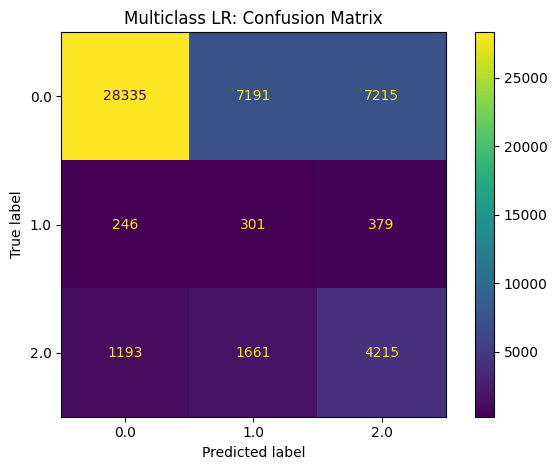

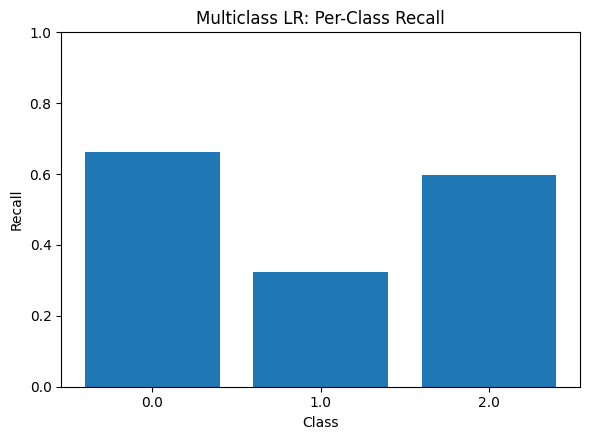

In [ ]:
# Multiclass LR: confusion matrix + per-class recall bars
# Load the trained multiclass LR model
lr_mc = best_mc["model"]
# Predict on the test set
mc_pred = lr_mc.predict(X_test)
mc_labels = lr_mc.classes_

# Confusion matrix
plt.figure(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, mc_pred, display_labels=mc_labels)
plt.title("Multiclass LR: Confusion Matrix")
plt.tight_layout()
plt.show()

# Per-class recall
per_class_recall = recall_score(y_test, mc_pred, average=None, labels=mc_labels)

# Per-class recall bar chart
plt.figure(figsize=(6, 4.5))
plt.bar(mc_labels.astype(str), per_class_recall)
plt.ylim(0, 1)
plt.title("Multiclass LR: Per-Class Recall")
plt.xlabel("Class")
plt.ylabel("Recall")
plt.tight_layout()
plt.show()

In [ ]:
# Task 2: Multiclass Classification (0 vs 1 vs 2) (Diagnosis) with LightGBM
# Gradient-boosted tree baseline with early stopping on validation
lgbm = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    learning_rate=0.05,
    n_estimators=5000,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    verbosity=-1
)

# Fit with early stopping on validation set
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# Report the best iteration found during early stopping
print("Best iteration:", lgbm.best_iteration_)

# Predict on the test set
test_pred = lgbm.predict(X_test)

# Print test metrics for the final model
print("\n=== LightGBM FINAL (TEST) ===")
print("Balanced Accuracy:", balanced_accuracy_score(y_test, test_pred))
print("Macro F1:", f1_score(y_test, test_pred, average="macro"))
print("Per-class Recall:", recall_score(y_test, test_pred, average=None, labels=lgbm.classes_))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_pred))

Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[5000]	valid_0's multi_logloss: 0.601247
Best iteration: 5000

=== LightGBM FINAL (TEST) ===
Balanced Accuracy: 0.48019254188464705
Macro F1: 0.4341004328214577
Per-class Recall: [0.76774058 0.03455724 0.63827981]
Confusion Matrix:
 [[32814  1448  8479]
 [  450    32   444]
 [ 2271   286  4512]]


<Figure size 550x450 with 0 Axes>

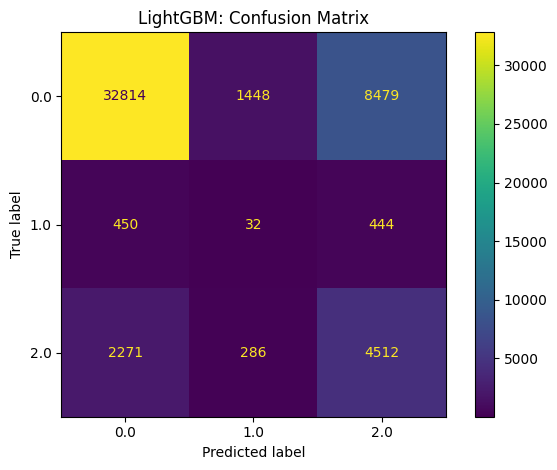

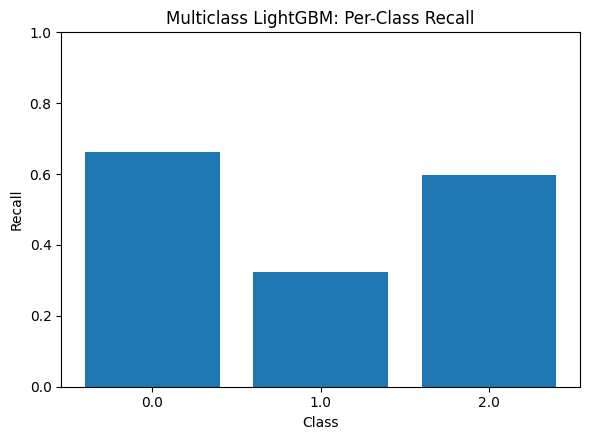

In [ ]:
# LightGBM: confusion matrix
# Predict on the test set
lgbm_pred = lgbm.predict(X_test)
lgbm_labels = lgbm.classes_

# Confusion matrix
plt.figure(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, lgbm_pred, display_labels=lgbm_labels)
plt.title("LightGBM: Confusion Matrix")
plt.tight_layout()
plt.show()

# LightGBM: per-class recall bars
plt.figure(figsize=(6, 4.5))
plt.bar(lgbm_labels.astype(str), per_class_recall)
plt.ylim(0, 1)
plt.title("Multiclass LightGBM: Per-Class Recall")
plt.xlabel("Class")
plt.ylabel("Recall")
plt.tight_layout()
plt.show()

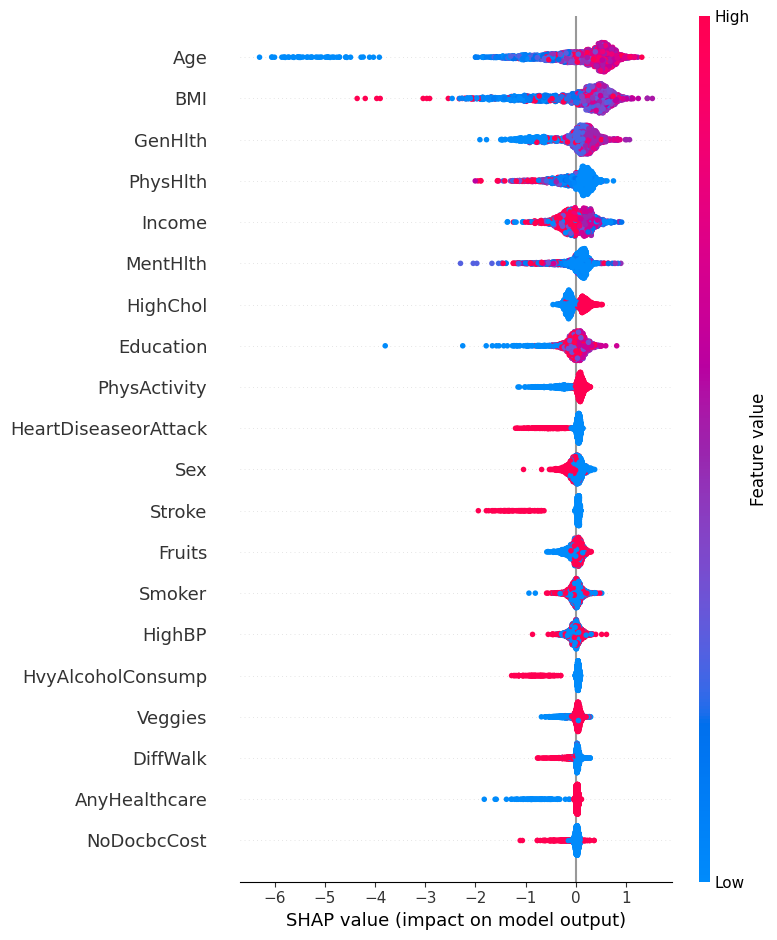

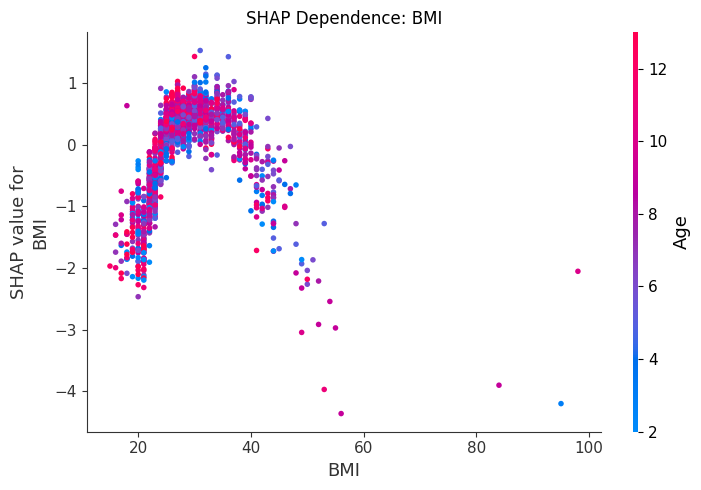

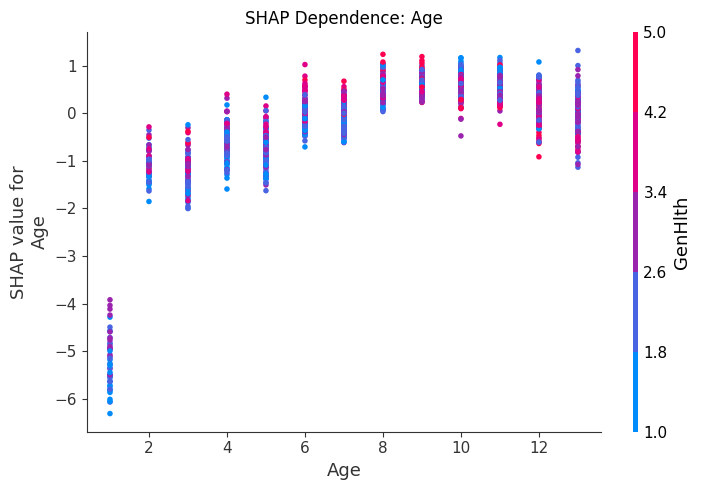

In [ ]:
# SHAP analysis for LightGBM feature effects
# Sample for faster SHAP plots
X_shap = X_test.copy()
if len(X_shap) > 2000:
    X_shap = X_shap.sample(2000, random_state=RANDOM_STATE)

# Build SHAP explainer
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_shap)

# Pick a reference class (prefer diabetes=1 if present)
class_names = list(getattr(lgbm, "classes_", [0, 1, 2]))
positive_class_idx = class_names.index(1) if 1 in class_names else 0

# Normalize SHAP output to (n_samples, n_features) for the selected class
if isinstance(shap_values, list):
    shap_values_pos = shap_values[positive_class_idx]
else:
    shap_values_pos = shap_values[:, :, positive_class_idx]

# Global SHAP summary (directionality)
shap.summary_plot(
    shap_values_pos,
    X_shap,
    feature_names=X_shap.columns,
    show=True
)

# Top features for dependence plots
mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)
selected_features = X_shap.columns[np.argsort(mean_abs_shap)[-2:]]

# Dependence plots for selected features
for feature in selected_features:
    shap.dependence_plot(
        feature,
        shap_values_pos,
        X_shap,
        show=False
    )
    plt.title(f"SHAP Dependence: {feature}")
    plt.tight_layout()
    plt.show()

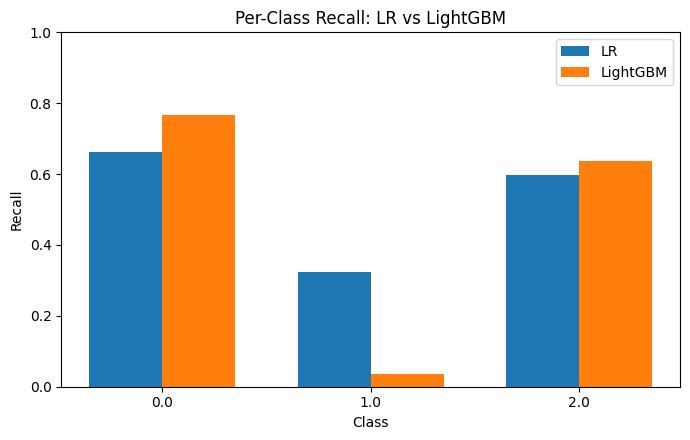

In [ ]:
# Per-class recall comparison: LR vs LightGBM (single plot)
# Predict with LightGBM
lgbm_pred = lgbm.predict(X_test)
lgbm_labels = lgbm.classes_

# Compute LightGBM per-class recall
lgbm_per_class_recall = recall_score(
    y_test, lgbm_pred, average=None, labels=lgbm_labels
 )

# Prepare bar positions and labels
labels = mc_labels.astype(str)
x = np.arange(len(labels))
bar_width = 0.35

# Side-by-side bar plot
plt.figure(figsize=(7.0, 4.5))
plt.bar(x - bar_width / 2, per_class_recall, width=bar_width, label="LR")
plt.bar(x + bar_width / 2, lgbm_per_class_recall, width=bar_width, label="LightGBM")
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.title("Per-Class Recall: LR vs LightGBM")
plt.xlabel("Class")
plt.ylabel("Recall")
plt.legend()
plt.tight_layout()
plt.show()